## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
from fuzzywuzzy import fuzz
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_ID = 'EL30'

In [3]:
dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022_new.csv", encoding = enc)
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,rainfall,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2010-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.812763,38.047451,1,2010,0.238709,0.125007,-0.093093,-0.125007,0.237988,0.124278,-0.095426,-0.124278,0.038738,0.029813,0.027037,0.029813,11.580251,5.941828,8.761039,3.872248,2164.888889,12606.363594,1411.887616,6.555556,192.192337,273.387005,184.906154,0.000000,18.522840,9160.777000,218.919640,1,143.099324,145.260138,173.755606,0.0,1.000000,14600.648385,3472.916707,19,260.150015,628.465808,197.888989,0.000000,168.454051,1791.885097,957.640750,5.585930,32.662113,133.294399,6.282653,0.000000,40.253180,32,9,30,13,13,10,8,9,2,0.578889,17.782222,120.039680,0,19.750000,20.000000,45.454545,859.836137,44.0,0.0,44.0,14.833333,30.833333,30.833333,9.333333,843.0,213.0,0.0,83.792957,346.0,70.0,70.0,332.0,45883.0,200375.0,47279.0,293537.0,43595.0,220412.0,60276.0,324283.0,18689.14,NaN,NaN
1,2010-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.685082,38.018504,1,2010,0.148037,0.048113,-0.115208,-0.048113,0.132420,0.041732,-0.098505,-0.041732,0.012587,0.012635,0.018510,0.012635,13.860538,7.126918,10.493728,3.617110,2596.888889,7456.110931,1302.303353,2.888889,179.452991,88.053120,178.742252,0.000000,31.947718,2863.059992,102.938851,1,156.039238,40.279633,177.635449,0.0,2.652014,10104.114693,2729.783246,7,254.428722,169.911207,180.359036,0.000000,247.581759,2186.799696,738.358541,2.619372,29.579501,38.211263,0.806462,0.000000,80.876525,1,9,1,13,13,10,8,9,2,1.052222,19.014444,112.130405,0,21.333333,20.500000,45.555556,895.781359,46.0,1.0,45.0,15.666667,32.833333,32.833333,10.500000,806.0,204.0,0.0,83.719908,324.0,59.0,59.0,308.0,38921.0,179791.0,33796.0,252508.0,36714.0,177899.0,44828.0,259441.0,7131.89,NaN,NaN
2,2010-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.754944,37.979104,1,2010,0.199024,0.129720,-0.038309,-0.129720,0.183807,0.120342,-0.036695,-0.120342,0.056233,0.037885,0.038611,0.037885,12.876044,6.630647,9.753346,3.644949,2375.526316,7725.713958,1929.044169,12.631579,217.737764,192.754855,192.653803,0.000671,19.794241,1841.397281,257.794377,2,170.379592,27.194326,182.858511,0.0,1.000000,11887.290117,3598.481563,36,252.283631,356.145800,218.102250,0.006370,249.240314,2678.000031,1043.392546,11.605605,22.744474,110.564188,10.298784,0.002009,57.297140,1,9,1,13,13,10,8,9,2,0.379474,18.605789,112.993420,0,20.458333,19.583333,44.507576,856.116584,44.0,0.0,44.0,15.500000,31.500000,31.500000,10.000000,800.0,199.0,0.0,85.292444,324.0,54.0,54.0,321.0,64868.0,377784.0,79042.0,521694.0,61544.0,388717.0,118883.0,569144.0,39021.83,NaN,NaN
3,2010-01,EL30,αττικη,EL304,νοτιος τομεας αθηνων,23.749555,37.914897,1,2010,0.221100,0.092933,-0.119241,-0.092933,0.205771,0.089282,-0.109884,-0.089282,0.036622,0.016738,0.032846,0.016738,12.310000,5.834968,9.072484,3.556352,2468.400000,3118.225377,1378.866538,7.500000,219.057236,124.615969,192.377664,0.000000,3.093557

<AxesSubplot:>

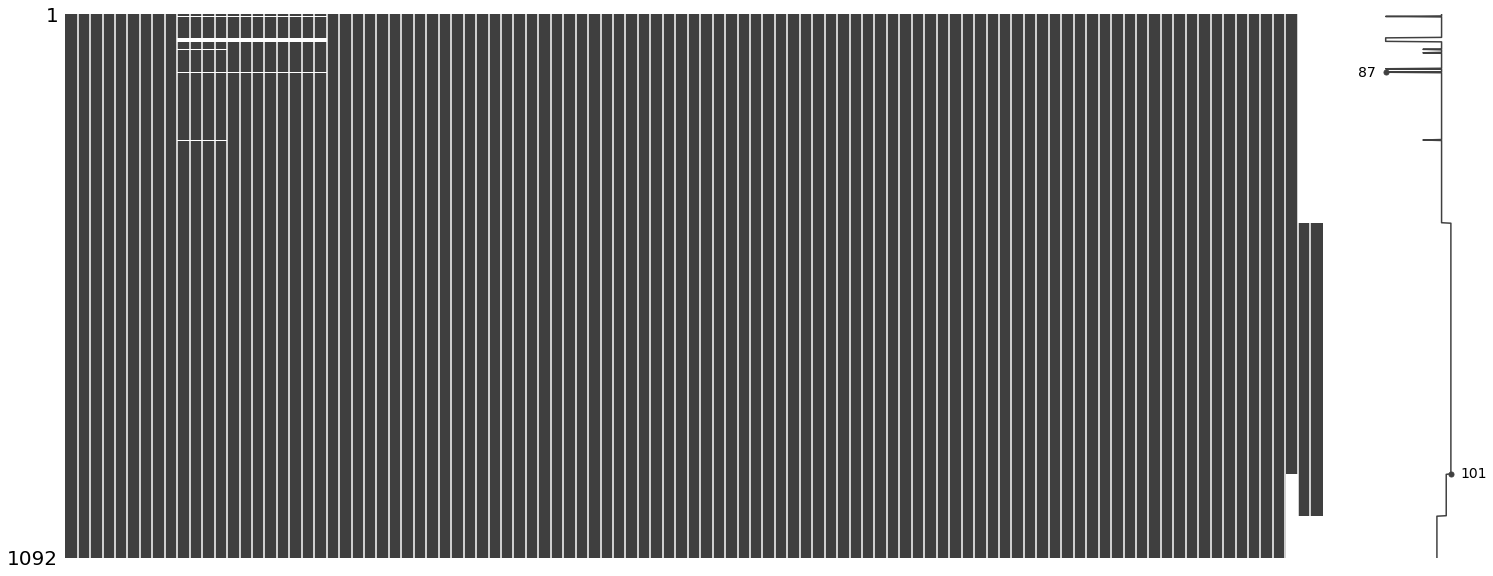

In [4]:
missingno.matrix(dataset_monthly)

In [5]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
0,ndvi,1.2821
1,ndmi,1.2821
2,ndwi,1.2821
3,ndbi,1.2821
4,ndvi_mean,1.0073
5,ndmi_mean,1.0073
6,ndwi_mean,1.0073
7,ndbi_mean,1.0073
8,ndvi_std,1.0073
9,ndmi_std,1.0073


In [6]:
years = dataset_monthly.year.unique()
nuts3_units = dataset_monthly.NUTS3_ID.unique()

In [7]:
data_p1 = []
data_p2 = []

for year in years[1:]:
    for region in nuts3_units:
        df_regional = dataset_monthly.loc[(dataset_monthly['NUTS3_ID'] == region)].copy()
        df_regional.reset_index(drop = True, inplace = True)

        df_period_1 = df_regional.loc[((df_regional['year'] == year-1) & (df_regional['month'] >= 11)) | ((df_regional['year'] == year) & (df_regional['month'] == 1))].copy()
        df_period_2 = df_regional.loc[((df_regional['year'] == year-1) & (df_regional['month'] >= 11)) | ((df_regional['year'] == year) & (df_regional['month'] <= 4))].copy()
        #df_period_2 = df_regional.loc[(df_regional['year'] == 2011) & (df_regional['month'] >= 2) & (df_regional['month'] <= 4)].copy()
        df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
        df_curr_year = df_regional.loc[(df_regional['year'] == year)].copy()

        x = df_curr_year['x'].mean()
        y = df_curr_year['y'].mean()

        ndvi_p1 = df_period_1['ndvi'].mean()
        ndwi_p1 = df_period_1['ndwi'].mean()
        ndmi_p1 = df_period_1['ndmi'].mean()
        ndbi_p1 = df_period_1['ndbi'].mean()

        ndvi_p2 = df_period_2['ndvi'].mean()
        ndwi_p2 = df_period_2['ndwi'].mean()
        ndmi_p2 = df_period_2['ndmi'].mean()
        ndbi_p2 = df_period_2['ndbi'].mean()
        #------------------------------------------------------
        lst_mean_p1 = df_period_1['lst'].mean()
        lst_day_mean_p1 = df_period_1['lst_day'].mean()
        lst_night_mean_p1 = df_period_1['lst_night'].mean()
        lst_min_p1 = df_period_1['monthly_lst_min'].min()
        lst_max_p1 = df_period_1['monthly_lst_min'].max()

        lst_mean_p2 = df_period_2['lst'].mean()
        lst_day_mean_p2 = df_period_2['lst_day'].mean()
        lst_night_mean_p2 = df_period_2['lst_night'].mean()
        lst_min_p2 = df_period_2['monthly_lst_min'].min()
        lst_max_p2 = df_period_2['monthly_lst_min'].max()
        #-------------------------------------------------------
        prec_mean_p1 = df_period_1['rainfall'].mean()
        prec_acc_p1 = df_period_1['monthly_acc_prec'].sum()

        prec_mean_p2 = df_period_2['rainfall'].mean()
        prec_acc_p2 = df_period_2['monthly_acc_prec'].sum()
        #-------------------------------------------------------
        mosq_mean_p1 = df_period_1['mosq_pred'].mean()
        mosq_sum_p1 = df_period_1['mosq_pred'].sum()

        mosq_mean_p2 = df_period_2['mosq_pred'].mean()
        mosq_sum_p2 = df_period_2['mosq_pred'].sum()
        #--------------------------------------------------------
        bio1 = df_prev_year.iloc[0]['bio1']
        bio2 = df_prev_year.iloc[0]['bio2']
        bio3 = df_prev_year.iloc[0]['bio3']
        bio4 = df_prev_year.iloc[0]['bio4']
        bio5 = df_prev_year.iloc[0]['bio5']
        bio6 = df_prev_year.iloc[0]['bio6']
        bio7 = df_prev_year.iloc[0]['bio7']
        bio8 = df_prev_year.iloc[0]['bio8']
        bio9 = df_prev_year.iloc[0]['bio9']
        bio10 = df_prev_year.iloc[0]['bio10']
        bio11 = df_prev_year.iloc[0]['bio11']
        bio12 = df_prev_year.iloc[0]['bio12']
        bio13 = df_prev_year.iloc[0]['bio13']
        bio14 = df_prev_year.iloc[0]['bio14']
        bio15 = df_prev_year.iloc[0]['bio15']
        bio16 = df_prev_year.iloc[0]['bio16']
        bio17 = df_prev_year.iloc[0]['bio17']
        bio18 = df_prev_year.iloc[0]['bio18']
        bio19 = df_prev_year.iloc[0]['bio19']
        #--------------------------------------------------------
        lc_prop1 = df_prev_year.iloc[0]['lc_prop1']
        lc_prop2 = df_prev_year.iloc[0]['lc_prop2']
        lc_prop3 = df_prev_year.iloc[0]['lc_prop3']
        lc_type1 = df_prev_year.iloc[0]['lc_type1']
        lc_type2 = df_prev_year.iloc[0]['lc_type2']
        lc_type3 = df_prev_year.iloc[0]['lc_type3']
        lc_type4 = df_prev_year.iloc[0]['lc_type4']
        lc_type5 = df_prev_year.iloc[0]['lc_type5']
        #--------------------------------------------------------
        distance_to_coast = df_prev_year.iloc[0]['distance_to_coast']
        distance_to_river = df_prev_year.iloc[0]['distance_to_river']
        slope_mean_1km = df_prev_year.iloc[0]['slope_mean_1km']
        aspect_mean_200m = df_prev_year.iloc[0]['aspect_mean_200m']
        elevation_mean_1km = df_prev_year.iloc[0]['elevation_mean_1km']
        hillshade_mean_1km = df_prev_year.iloc[0]['hillshade_mean_1km']
        fs_area_1km = df_prev_year.iloc[0]['fs_area_1km']
        flow_accu_200m = df_prev_year.iloc[0]['flow_accu_200m']

        distance_to_coast_std = df_prev_year.iloc[0]['distance_to_coast_std']
        distance_to_river_std = df_prev_year.iloc[0]['distance_to_river_std']
        slope_mean_1km_std = df_prev_year.iloc[0]['slope_mean_1km_std']
        aspect_mean_200m_std = df_prev_year.iloc[0]['aspect_mean_200m_std']
        elevation_mean_1km_std = df_prev_year.iloc[0]['elevation_mean_1km_std']
        hillshade_mean_1km_std = df_prev_year.iloc[0]['hillshade_mean_1km_std']
        fs_area_1km_std = df_prev_year.iloc[0]['fs_area_1km_std']
        flow_accu_200m_std = df_prev_year.iloc[0]['flow_accu_200m_std']
        #--------------------------------------------------------
        males_lt15 = df_prev_year.iloc[0]['M_Y_LT15']
        males_15t64 = df_prev_year.iloc[0]['M_Y15-64']
        males_gt65 = df_prev_year.iloc[0]['M_Y_GE65']
        males_total = df_prev_year.iloc[0]['M_TOTAL']

        females_lt15 = df_prev_year.iloc[0]['F_Y_LT15']
        females_15t64 = df_prev_year.iloc[0]['F_Y15-64']
        females_gt65 = df_prev_year.iloc[0]['F_Y_GE65']
        females_total = df_prev_year.iloc[0]['F_TOTAL']

        mio_eur = df_prev_year.iloc[0]['MIO_EUR']
        l_total = df_prev_year.iloc[0]['L_TOTAL']
        unl_total = df_prev_year.iloc[0]['UNL_TOTAL']
        #--------------------------------------------------------
        cases_total = df_curr_year['cases'].sum()
        cases_arr = df_curr_year.loc[(df_curr_year['month'] >= 5) & (df_curr_year['month'] <= 10)]['cases'].to_list()

        data_p1.append({'NUTS3_ID': region, 
                     'year': year, 
                     'x' : x,
                     'y': y,
                     'ndvi_p1': ndvi_p1,
                     'ndwi_p1': ndwi_p1,
                     'ndmi_p1': ndmi_p1,
                     'ndbi_p1': ndbi_p1,
                     'lst_mean_p1': lst_mean_p1,
                     'lst_day_mean_p1': lst_day_mean_p1,
                     'lst_night_mean_p1': lst_night_mean_p1,
                     'lst_min_p1': lst_min_p1,
                     'lst_max_p1': lst_max_p1,
                     'prec_mean_p1': prec_mean_p1,
                     'prec_acc_p1': prec_acc_p1,
                     'mosq_mean_p1': mosq_mean_p1,
                     'mosq_sum_p1': mosq_sum_p1,
                     'bio1': bio1,
                     'bio2': bio2,
                     'bio3': bio3,
                     'bio4': bio4,
                     'bio5': bio5,
                     'bio6': bio6,
                     'bio7': bio7,
                     'bio8': bio8,
                     'bio9': bio9,
                     'bio10': bio10,
                     'bio11': bio11,
                     'bio12': bio12,
                     'bio13': bio13,
                     'bio14': bio14,
                     'bio15': bio15,
                     'bio16': bio16,
                     'bio17': bio17,
                     'bio18': bio18,
                     'bio19': bio19,
                     'lc_prop1': lc_prop1,
                     'lc_prop2': lc_prop2,
                     'lc_prop3': lc_prop3,
                     'lc_type1': lc_type1,
                     'lc_type2': lc_type2,
                     'lc_type3': lc_type3,
                     'lc_type4': lc_type4,
                     'lc_type5': lc_type5,
                     'distance_to_coast': distance_to_coast,
                     'distance_to_river': distance_to_river,
                     'slope_mean_1km': slope_mean_1km,
                     'aspect_mean_200m': aspect_mean_200m,
                     'elevation_mean_1km': elevation_mean_1km,
                     'hillshade_mean_1km': hillshade_mean_1km,
                     'fs_area_1km': fs_area_1km,
                     'flow_accu_200m': flow_accu_200m,
                     'distance_to_coast_std': distance_to_coast_std,
                     'distance_to_river_std': distance_to_river_std,
                     'slope_mean_1km_std': slope_mean_1km_std,
                     'aspect_mean_200m_std': aspect_mean_200m_std,
                     'elevation_mean_1km_std': elevation_mean_1km_std,
                     'hillshade_mean_1km_std': hillshade_mean_1km_std,
                     'fs_area_1km_std': fs_area_1km_std,
                     'flow_accu_200m_std': flow_accu_200m_std,
                     'males_lt15': males_lt15,
                     'males_15t64': males_15t64,
                     'males_gt65': males_gt65,
                     'males_total': males_total,
                     'females_lt15': females_lt15,
                     'females_15t64': females_15t64,
                     'females_gt65': females_gt65,
                     'females_total': females_total,
                     'mio_eur': mio_eur,
                     'l_total': l_total,
                     'unl_total': unl_total,
                     'mio_eur': mio_eur,
                     'cases_total': cases_total,
                     'cases_arr': cases_arr,
                     })

        data_p2.append({'NUTS3_ID': region, 
                     'year': year,
                     'x' : x,
                     'y': y, 
                     'ndvi_p1': ndvi_p2,
                     'ndwi_p1': ndwi_p2,
                     'ndmi_p1': ndmi_p2,
                     'ndbi_p1': ndbi_p2,
                     'lst_mean_p1': lst_mean_p2,
                     'lst_day_mean_p1': lst_day_mean_p2,
                     'lst_night_mean_p1': lst_night_mean_p2,
                     'lst_min_p1': lst_min_p2,
                     'lst_max_p1': lst_max_p2,
                     'prec_mean_p1': prec_mean_p2,
                     'prec_acc_p1': prec_acc_p2,
                     'mosq_mean_p1': mosq_mean_p2,
                     'mosq_sum_p1': mosq_sum_p2,
                     'bio1': bio1,
                     'bio2': bio2,
                     'bio3': bio3,
                     'bio4': bio4,
                     'bio5': bio5,
                     'bio6': bio6,
                     'bio7': bio7,
                     'bio8': bio8,
                     'bio9': bio9,
                     'bio10': bio10,
                     'bio11': bio11,
                     'bio12': bio12,
                     'bio13': bio13,
                     'bio14': bio14,
                     'bio15': bio15,
                     'bio16': bio16,
                     'bio17': bio17,
                     'bio18': bio18,
                     'bio19': bio19,
                     'lc_prop1': lc_prop1,
                     'lc_prop2': lc_prop2,
                     'lc_prop3': lc_prop3,
                     'lc_type1': lc_type1,
                     'lc_type2': lc_type2,
                     'lc_type3': lc_type3,
                     'lc_type4': lc_type4,
                     'lc_type5': lc_type5,
                     'distance_to_coast': distance_to_coast,
                     'distance_to_river': distance_to_river,
                     'slope_mean_1km': slope_mean_1km,
                     'aspect_mean_200m': aspect_mean_200m,
                     'elevation_mean_1km': elevation_mean_1km,
                     'hillshade_mean_1km': hillshade_mean_1km,
                     'fs_area_1km': fs_area_1km,
                     'flow_accu_200m': flow_accu_200m,
                     'distance_to_coast_std': distance_to_coast_std,
                     'distance_to_river_std': distance_to_river_std,
                     'slope_mean_1km_std': slope_mean_1km_std,
                     'aspect_mean_200m_std': aspect_mean_200m_std,
                     'elevation_mean_1km_std': elevation_mean_1km_std,
                     'hillshade_mean_1km_std': hillshade_mean_1km_std,
                     'fs_area_1km_std': fs_area_1km_std,
                     'flow_accu_200m_std': flow_accu_200m_std,
                     'males_lt15': males_lt15,
                     'males_15t64': males_15t64,
                     'males_gt65': males_gt65,
                     'males_total': males_total,
                     'females_lt15': females_lt15,
                     'females_15t64': females_15t64,
                     'females_gt65': females_gt65,
                     'females_total': females_total,
                     'mio_eur': mio_eur,
                     'l_total': l_total,
                     'unl_total': unl_total,
                     'mio_eur': mio_eur,
                     'cases_total': cases_total,
                     'cases_arr': cases_arr,
                     })
        
p1_df = pd.DataFrame(data_p1)       
p2_df = pd.DataFrame(data_p2) 

In [8]:
p1_df

,NUTS3_ID,year,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL301,2011,23.812763,38.047451,0.190114,-0.022010,0.142095,-0.142095,11.834603,15.194800,8.474407,1.150000,9.631111,3.193722,295.331599,576.111111,1728.333333,19.750000,20.000000,45.454545,859.836137,44.0,0.0,44.0,14.833333,30.833333,30.833333,9.333333,843.0,213.0,0.0,83.792957,346.0,70.0,70.0,332.0,32,9,30,13,13,10,8,9,12606.363594,1411.887616,6.555556,192.192337,273.387005,184.906154,0.000000,18.522840,1791.885097,957.640750,5.585930,32.662113,133.294399,6.282653,0.000000,40.253180,45883.0,200375.0,47279.0,293537.0,43595.0,220412.0,60276.0,324283.0,18689.14,NaN,NaN,3,"[0, 0, 0, 1, 1, 1]"
1,EL302,2011,23.685082,38.018504,0.346850,-0.177408,0.153965,-0.153965,12.589881,15.931971,9.247792,2.652222,8.874444,3.080417,284.854293,753.074074,2259.222222,21.333333,20.500000,45.555556,895.781359,46.0,1.0,45.0,15.666667,32.833333,32.833333,10.500000,806.0,204.0,0.0,83.719908,324.0,59.0,59.0,308.0,1,9,1,13,13,10,8,9,7456.110931,1302.303353,2.888889,179.452991,88.053120,178.742252,0.000000,31.947718,2186.799696,738.358541,2.619372,29.579501,38.211263,0.806462,0.000000,80.876525,38921.0,179791.0,33796.0,252508.0,36714.0,177899.0,44828.0,259441.0,7131.89,NaN,NaN,1,"[0, 0, 0, 0, 1, 0]"
2,EL303,2011,23.754944,37.979104,0.178891,-0.035509,0.115201,-0.115201,12.473025,15.219113,9.726937,2.391053,10.566842,3.115267,288.063662,677.701754,2033.105263,20.458333,19.583333,44.507576,856.116584,44.0,0.0,44.0,15.500000,31.500000,31.500000,10.000000,800.0,199.0,0.0,85.292444,324.0,54.0,54.0,321.0,1,9,1,13,13,10,8,9,7725.713958,1929.044169,12.631579,217.737764,192.754855,192.653803,0.000671,19.794241,2678.000031,1043.392546,11.605605,22.744474,110.564188,10.298784,0.002009,57.297140,64868.0,377784.0,79042.0,521694.0,61544.0,388717.0,118883.0,569144.0,39021.83,NaN,NaN,1,"[0, 0, 0, 0, 0, 1]"
3,EL304,2011,23.749555,37.914897,0.180365,-0.066327,0.096891,-0.096891,12.469814,15.226632,9.712996,-3.388000,10.878000,3.122400,288.749840,683.066667,2049.200000,20.666667,19.500000,42.391304,866.637529,44.0,-2.0,46.0,9.833333,31.500000,31.500000,9.833333,779.0,192.0,0.0,86.033662,317.0,46.0,46.0,317.0,32,9,30,13,13,10,8,9,3118.225377,1378.866538,7.500000,219.057236,124.615969,192.377664,0.000000,3.093557,1344.876620,533.113240,5.759051,18.911152,115.459129,9.538529,0.000000,2.890222,38993.0,183267.0,41033.0,263293.0,36789.0,199070.0,55549.0,291408.0,12606.74,NaN,NaN,2,"[0, 0, 0, 0, 1, 1]"
4,EL305,2011,23.889386,38.042726,0.305248,-0.099524,0.162040,-0.162040,11.458972,14.819926,8.098017,0.098000,8.792552,3.406621,314.889622,496.831034,1490.493103,19.416667,21.000000,47.727273,855.685088,44.0,0.0,44.0,14.500000,30.500000,30.500000,9.333333,868.0,219.0,0.0,83.901842,363.0,71.0,71.0,342.0,31,30,30,10,10,1,6,6,5657.468218,2280.387151,9.272414,166.316678,277.715457,177.019093,0.000000,4.069978,3224.864575,942.777050,6.001580,52.692676,207.986089,9.842805,0.000000,3.959379,43417.0,180372.0,35396.0,259185.0,41239.0,171976.0,38828.0,252043.0,13091.44,NaN,NaN,20,"[0, 0, 7, 8, 5, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [9]:
p2_df

,NUTS3_ID,year,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL301,2011,23.812763,38.047451,0.224391,-0.098679,0.115567,-0.115567,12.186157,16.328165,8.044150,-0.817778,9.631111,5.020633,894.054687,452.500000,2715.000000,19.750000,20.000000,45.454545,859.836137,44.0,0.0,44.0,14.833333,30.833333,30.833333,9.333333,843.0,213.0,0.0,83.792957,346.0,70.0,70.0,332.0,32,9,30,13,13,10,8,9,12606.363594,1411.887616,6.555556,192.192337,273.387005,184.906154,0.000000,18.522840,1791.885097,957.640750,5.585930,32.662113,133.294399,6.282653,0.000000,40.253180,45883.0,200375.0,47279.0,293537.0,43595.0,220412.0,60276.0,324283.0,18689.14,NaN,NaN,3,"[0, 0, 0, 1, 1, 1]"
1,EL302,2011,23.685082,38.018504,0.215664,-0.157479,0.069613,-0.069613,13.354924,17.458534,9.251314,-2.941111,9.761111,5.046993,898.053916,560.574074,3363.444444,21.333333,20.500000,45.555556,895.781359,46.0,1.0,45.0,15.666667,32.833333,32.833333,10.500000,806.0,204.0,0.0,83.719908,324.0,59.0,59.0,308.0,1,9,1,13,13,10,8,9,7456.110931,1302.303353,2.888889,179.452991,88.053120,178.742252,0.000000,31.947718,2186.799696,738.358541,2.619372,29.579501,38.211263,0.806462,0.000000,80.876525,38921.0,179791.0,33796.0,252508.0,36714.0,177899.0,44828.0,259441.0,7131.89,NaN,NaN,1,"[0, 0, 0, 0, 1, 0]"
2,EL303,2011,23.754944,37.979104,0.194436,-0.084023,0.096446,-0.096446,13.034510,16.857031,9.211988,-1.353158,10.566842,4.953829,882.292572,528.614035,3171.684211,20.458333,19.583333,44.507576,856.116584,44.0,0.0,44.0,15.500000,31.500000,31.500000,10.000000,800.0,199.0,0.0,85.292444,324.0,54.0,54.0,321.0,1,9,1,13,13,10,8,9,7725.713958,1929.044169,12.631579,217.737764,192.754855,192.653803,0.000671,19.794241,2678.000031,1043.392546,11.605605,22.744474,110.564188,10.298784,0.002009,57.297140,64868.0,377784.0,79042.0,521694.0,61544.0,388717.0,118883.0,569144.0,39021.83,NaN,NaN,1,"[0, 0, 0, 0, 0, 1]"
3,EL304,2011,23.749555,37.914897,0.202317,-0.120640,0.078714,-0.078714,12.963135,16.882328,9.043942,-3.388000,10.878000,4.947449,881.527123,532.400000,3194.400000,20.666667,19.500000,42.391304,866.637529,44.0,-2.0,46.0,9.833333,31.500000,31.500000,9.833333,779.0,192.0,0.0,86.033662,317.0,46.0,46.0,317.0,32,9,30,13,13,10,8,9,3118.225377,1378.866538,7.500000,219.057236,124.615969,192.377664,0.000000,3.093557,1344.876620,533.113240,5.759051,18.911152,115.459129,9.538529,0.000000,2.890222,38993.0,183267.0,41033.0,263293.0,36789.0,199070.0,55549.0,291408.0,12606.74,NaN,NaN,2,"[0, 0, 0, 0, 1, 1]"
4,EL305,2011,23.889386,38.042726,0.361173,-0.176718,0.152526,-0.152526,11.448981,15.664586,7.233376,-0.894692,8.792552,5.189559,924.587091,378.149425,2268.896552,19.416667,21.000000,47.727273,855.685088,44.0,0.0,44.0,14.500000,30.500000,30.500000,9.333333,868.0,219.0,0.0,83.901842,363.0,71.0,71.0,342.0,31,30,30,10,10,1,6,6,5657.468218,2280.387151,9.272414,166.316678,277.715457,177.019093,0.000000,4.069978,3224.864575,942.777050,6.001580,52.692676,207.986089,9.842805,0.000000,3.959379,43417.0,180372.0,35396.0,259185.0,41239.0,171976.0,38828.0,252043.0,13091.44,NaN,NaN,20,"[0, 0, 7, 8, 5, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

<AxesSubplot:>

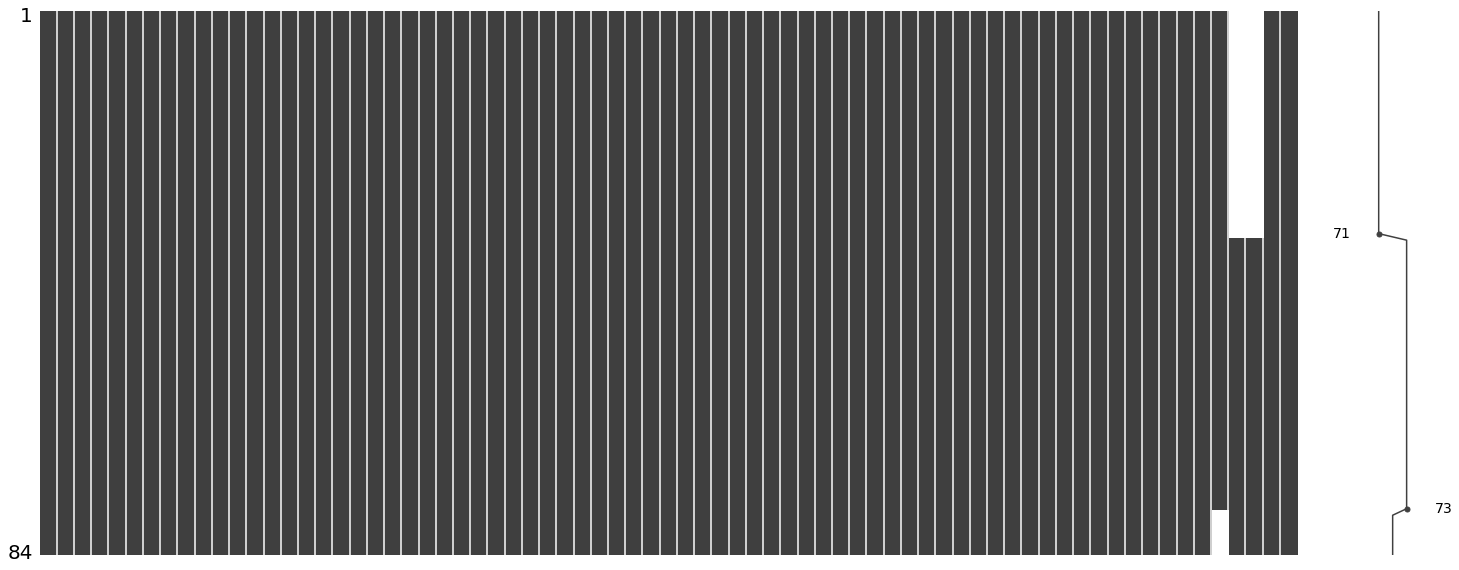

In [10]:
missingno.matrix(p1_df)

<AxesSubplot:>

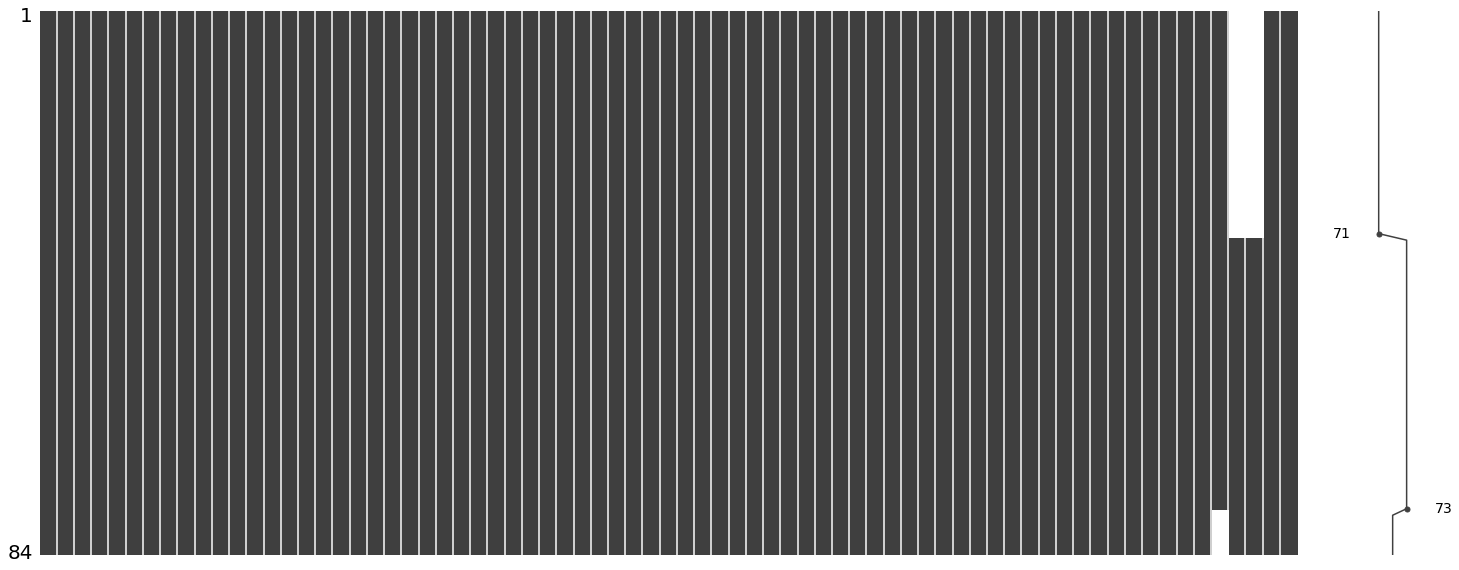

In [11]:
missingno.matrix(p2_df)

In [12]:
missing = describe_dataframe(p1_df, remove_zeros=True)
missing

,Column,Missing
0,mio_eur,8.3333
1,l_total,41.6667
2,unl_total,41.6667


In [13]:
missing = describe_dataframe(p2_df, remove_zeros=True)
missing

,Column,Missing
0,mio_eur,8.3333
1,l_total,41.6667
2,unl_total,41.6667


In [14]:
p1_df.cases_total.sum()

296

In [15]:
p2_df.cases_total.sum()

296

In [16]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'mio_eur']

temp_df = p1_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['mio_eur']

p1_df[imputed_columns] = imputed_data[imputed_columns]
p2_df[imputed_columns] = imputed_data[imputed_columns]

In [17]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'l_total']

temp_df = p1_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['l_total']

p1_df[imputed_columns] = imputed_data[imputed_columns]
p2_df[imputed_columns] = imputed_data[imputed_columns]

In [18]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'unl_total']

temp_df = p1_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['unl_total']

p1_df[imputed_columns] = imputed_data[imputed_columns]
p2_df[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

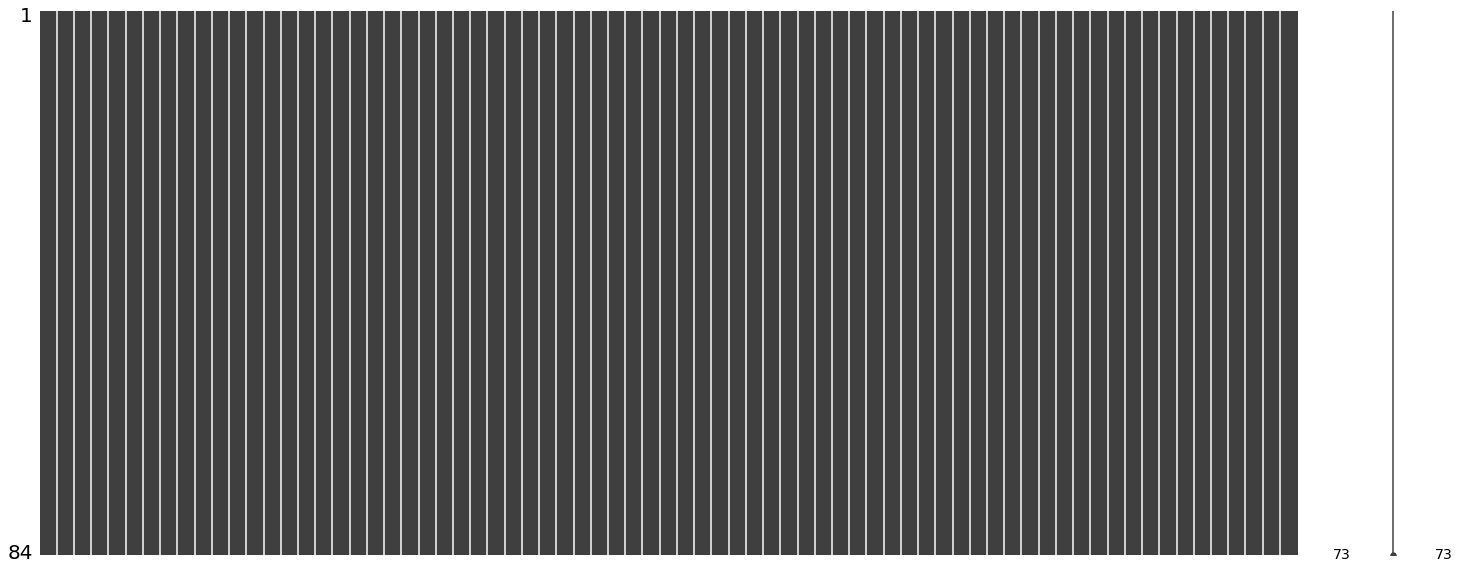

In [19]:
missingno.matrix(p1_df, label_rotation=90)

<AxesSubplot:>

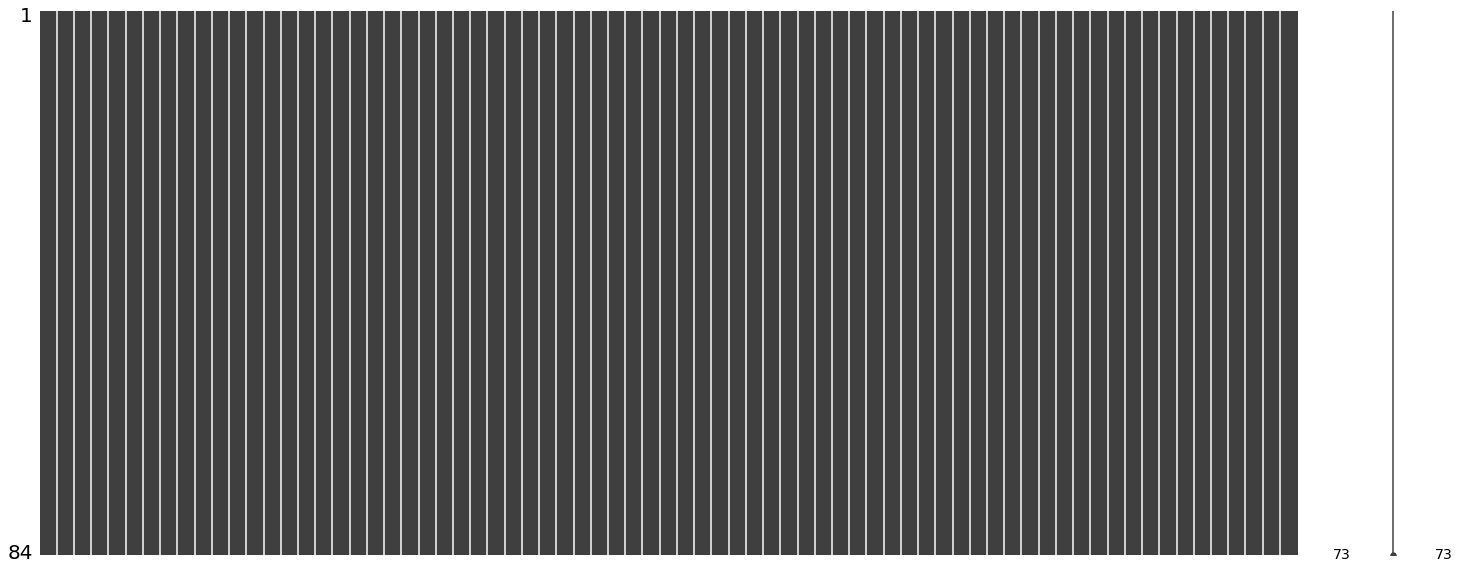

In [20]:
missingno.matrix(p2_df, label_rotation=90)

<AxesSubplot:>

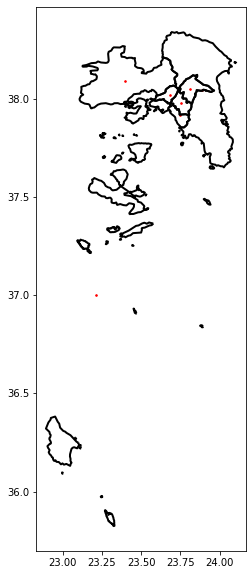

In [21]:
## Reading shapefiles from Greece

greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU/Greece/data/EL_Whole.shp",  encoding=enc)

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}']

nuts3_points = gpd.GeoDataFrame(p1_df[['NUTS3_ID']], geometry=gpd.points_from_xy(p1_df.x, p1_df.y))

ax = nuts3_points.head(7).plot(markersize=2.5, figsize=(10, 10), color='red')
nuts3_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [22]:
p1_df.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_P1_2011_2022.csv", encoding = enc, index = False)
p1_df.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_P2_2011_2022.csv", encoding = enc, index = False)